# FIX vs GO Neural Decoder - Phase 1: Data Preparation

This notebook implements Phase 1 of the Xie-style decoder following the plan in `FIX_GO_DECODER_PLAN.md`.

**Goal**: Prepare data for training a linear neural decoder to classify FIX mode (fixation) vs GO mode (saccade preparation/execution).

**Reference**: Xie et al. (2022) "Geometry of sequence working memory in macaque prefrontal cortex" - Figure 3A

## Phase 1 Checklist

- [ ] Load cell_df and compute mean_ssd2 per direction
- [ ] Filter GO trials (successful, RT > 1.3×mean_ssd2)
- [ ] Split by direction (0° and 180°)
- [ ] Extract epochs and labels
- [ ] Z-score normalize features
- [ ] Train/test split (stratified)

---

## 1. Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
import sys

# Add parent directory to path
sys.path.insert(0, str(Path.cwd().parent))

import importlib
import session_class
import cell_analysis
importlib.reload(session_class)
importlib.reload(cell_analysis)

from session_class import Session
from cell_analysis import Cell

# For train/test split
from sklearn.model_selection import train_test_split

print("Imports loaded successfully!")

Imports loaded successfully!


## 2. Configuration and Parameters

In [2]:
# Data paths
base_path = Path.cwd().parents[1] / 'data' / 'unified_cell_trial_data'
pickle_file = base_path / 'msn_fiona_cell_trial_data.pkl'

# Session selection (use multi-cell session for population analysis)
session_id = 'fi211025a'  # Starting session

# Parameters
SSD_NUM = 2  # SSD level to use for computing mean_ssd
RT_MULTIPLIER = 1.3  # GO trials must have RT > RT_MULTIPLIER × mean_ssd
TEST_SIZE = 0.2  # Fraction for test set
RANDOM_STATE = 42  # For reproducibility

# Epoch multipliers (relative to mean_ssd, aligned to go_cue)
EPOCH_DEFS = [
    # ('FIX_early', -2, -1, 0),  # (name, start_mult, end_mult, label: 0=FIX, 1=GO)
    ('FIX_late', -1, 0, 0),
    # ('GO_early', 0, 1, 1),
    ('GO_late', 1, 2, 1),
]

# Direction mapping
dir_map = {0: 'Right', 180: 'Left'}
directions = [0, 180]

print(f"Configuration:")
print(f"  Session: {session_id}")
print(f"  SSD level for mean_ssd: {SSD_NUM}")
print(f"  GO trial RT threshold: {RT_MULTIPLIER} × mean_ssd")
print(f"  Test set size: {TEST_SIZE * 100}%")
print(f"  Random state: {RANDOM_STATE}")

Configuration:
  Session: fi211025a
  SSD level for mean_ssd: 2
  GO trial RT threshold: 1.3 × mean_ssd
  Test set size: 20.0%
  Random state: 42


## 3. Load Data and Create Session

In [3]:
# Load MSN cell database
print("Loading cell database...")
cell_df = pd.read_pickle(pickle_file)
print(f"Total cell-trial combinations: {len(cell_df):,}")

# Select session
session_data = cell_df[cell_df['trial_session'] == session_id]
print(f"\nSession {session_id} data: {len(session_data):,} cell-trial combinations")

# Create Session object
session = Session(session_data, verbose=True)

# Drop cells with missing trial type or direction data
session.drop_cells_with_missing_trial_type_or_dir_data()

print(f"\n✓ Session {session_id} loaded successfully!")
print(f"  Number of cells: {session.n_cells}")
print(f"  Total cell-trial combinations: {len(session.data):,}")

Loading cell database...
Total cell-trial combinations: 1,906,402

Session fi211025a data: 104,543 cell-trial combinations
Session fi211025a initialized:
  - Number of cells: 150
  - Total trials: 1950
  - Trial types: ['CONT', 'GO', 'STOP']
  - Directions: [np.int64(0), np.int64(180)]

✓ Session fi211025a loaded successfully!
  Number of cells: 150
  Total cell-trial combinations: 104,543


## 4. Compute mean_ssd2 per Direction

Compute the mean SSD length for each direction using successful STOP trials at SSD level 2.

In [4]:
def compute_mean_ssd(session_data, direction, ssd_number):
    """
    Compute mean SSD length for a given direction and SSD level.
    
    Parameters:
    -----------
    session_data : DataFrame
        Session data
    direction : int
        0 (right) or 180 (left)
    ssd_number : int
        SSD level (typically 2)
    
    Returns:
    --------
    float : Mean SSD length in ms
    """
    stop_trials = session_data[
        (session_data['type'] == 'STOP') &
        (session_data['trial_failed'] == False) &
        (session_data['dir'] == direction) &
        (session_data['ssd_number'] == ssd_number)
    ]
    
    if len(stop_trials) == 0:
        raise ValueError(f"No STOP trials found for direction {direction}, SSD {ssd_number}")
    
    mean_ssd = stop_trials['ssd_len'].mean()
    return mean_ssd


# Compute mean_ssd for each direction
mean_ssd_dict = {}

print("Computing mean_ssd2 per direction:")
print("=" * 60)

for direction in directions:
    mean_ssd = compute_mean_ssd(session.data, direction, SSD_NUM)
    mean_ssd_dict[direction] = mean_ssd
    print(f"Direction {direction}° ({dir_map[direction]}): mean_ssd2 = {mean_ssd:.2f} ms")

print(f"\n✓ mean_ssd2 computed for both directions")

Computing mean_ssd2 per direction:
Direction 0° (Right): mean_ssd2 = 108.00 ms
Direction 180° (Left): mean_ssd2 = 108.00 ms

✓ mean_ssd2 computed for both directions


## 5. Filter GO Trials

Keep only successful GO trials with RT > 1.3 × mean_ssd2.
This ensures we have enough time to extract the GO_late epoch before saccade onset.

In [5]:
def filter_go_trials(session_data, direction, mean_ssd, rt_multiplier=1.3):
    """
    Filter GO trials based on success and reaction time.
    
    Parameters:
    -----------
    session_data : DataFrame
        Session data
    direction : int
        0 (right) or 180 (left)
    mean_ssd : float
        Mean SSD length for this direction
    rt_multiplier : float
        Multiplier for RT threshold (default 1.3)
    
    Returns:
    --------
    DataFrame : Filtered GO trials
    """
    # Base filter: GO trials, correct direction, successful
    mask = (
        (session_data['type'] == 'GO') &
        (session_data['dir'] == direction) &
        (session_data['trial_failed'] == False)
    )
    
    go_trials = session_data[mask].copy()
    
    # Filter by reaction time
    # RT must be > rt_multiplier × mean_ssd to ensure GO_late epoch fits before saccade
    rt_threshold = rt_multiplier * mean_ssd
    
    # reaction_time column should exist, but double-check
    if 'reaction_time' not in go_trials.columns:
        # Compute RT from first_relevant_saccade if needed
        def compute_rt(row):
            if pd.isna(row['first_relevant_saccade']).any():
                return np.nan
            return row['first_relevant_saccade'][0] - row['go_cue']
        
        go_trials['reaction_time'] = go_trials.apply(compute_rt, axis=1)
    
    # Apply RT filter
    valid_rt_mask = go_trials['reaction_time'] > rt_threshold
    filtered_go_trials = go_trials[valid_rt_mask]
    
    return filtered_go_trials


# Filter GO trials for each direction
filtered_data_by_dir = {}

print("Filtering GO trials per direction:")
print("=" * 60)

for direction in directions:
    mean_ssd = mean_ssd_dict[direction]
    rt_threshold = RT_MULTIPLIER * mean_ssd
    
    # Filter GO trials
    filtered_go = filter_go_trials(session.data, direction, mean_ssd, RT_MULTIPLIER)
    
    # Count original vs filtered
    original_go = session.data[
        (session.data['type'] == 'GO') &
        (session.data['dir'] == direction) &
        (session.data['trial_failed'] == False)
    ]
    
    n_original = len(original_go['trial_number'].unique())
    n_filtered = len(filtered_go['trial_number'].unique())
    n_removed = n_original - n_filtered
    
    filtered_data_by_dir[direction] = filtered_go
    
    print(f"\nDirection {direction}° ({dir_map[direction]}):")
    print(f"  RT threshold: > {rt_threshold:.2f} ms")
    print(f"  Original GO trials: {n_original}")
    print(f"  After RT filter: {n_filtered}")
    print(f"  Removed: {n_removed} ({n_removed/n_original*100:.1f}%)")

print(f"\n✓ GO trials filtered for both directions")

Filtering GO trials per direction:

Direction 0° (Right):
  RT threshold: > 140.40 ms
  Original GO trials: 526
  After RT filter: 435
  Removed: 91 (17.3%)

Direction 180° (Left):
  RT threshold: > 140.40 ms
  Original GO trials: 520
  After RT filter: 449
  Removed: 71 (13.7%)

✓ GO trials filtered for both directions


## 6. Extract Epoch Features

For each neuron and each trial, extract mean firing rate in each of the 4 epochs:
- FIX_early: [-2×mean_ssd, -1×mean_ssd] (label: FIX)
- FIX_late: [-1×mean_ssd, 0] (label: FIX)
- GO_early: [0, +1×mean_ssd] (label: GO)
- GO_late: [+1×mean_ssd, +2×mean_ssd] (label: GO)

In [6]:
def extract_epoch_firing_rate(spike_times, epoch_start, epoch_end):
    """
    Compute mean firing rate in a given epoch.
    
    Parameters:
    -----------
    spike_times : array-like
        Spike times relative to alignment point (e.g., go_cue)
    epoch_start : float
        Epoch start time (ms)
    epoch_end : float
        Epoch end time (ms)
    
    Returns:
    --------
    float : Firing rate in Hz
    """
    spikes_in_epoch = spike_times[
        (spike_times >= epoch_start) & (spike_times < epoch_end)
    ]
    duration_sec = (epoch_end - epoch_start) / 1000.0
    
    if duration_sec <= 0:
        return 0.0
    
    return len(spikes_in_epoch) / duration_sec


def extract_trial_epoch_features(trial_data, epoch_defs, mean_ssd, alignment_point='go_cue'):
    """
    Extract features for all epochs in a single trial.
    
    Parameters:
    -----------
    trial_data : Series
        Single trial row from session data
    epoch_defs : list of tuples
        [(name, start_mult, end_mult, label), ...]
    mean_ssd : float
        Mean SSD length for this direction
    alignment_point : str
        Column name for alignment (default 'go_cue')
    
    Returns:
    --------
    dict : {epoch_name: firing_rate}
    """
    # Get spike times relative to alignment point
    spike_times = np.array(trial_data['neural_data'], dtype=np.float64)  # Explicit dtype
    alignment_time = trial_data[alignment_point]
    relative_spikes = spike_times - alignment_time
    
    # Extract firing rate for each epoch
    features = {}
    for epoch_name, start_mult, end_mult, label in epoch_defs:
        epoch_start = start_mult * mean_ssd
        epoch_end = end_mult * mean_ssd
        fr = extract_epoch_firing_rate(relative_spikes, epoch_start, epoch_end)
        features[epoch_name] = fr
    
    return features


def build_feature_dataset(trial_data, epoch_defs, mean_ssd):
    """
    Build feature matrix and labels for decoder.
    
    Each row is a (trial, epoch) pair.
    Features: mean firing rate per neuron in that epoch.
    
    Parameters:
    -----------
    trial_data : DataFrame
        Filtered trial data (all cells for multiple trials)
    epoch_defs : list of tuples
        [(name, start_mult, end_mult, label), ...]
    mean_ssd : float
        Mean SSD length for this direction
    
    Returns:
    --------
    X : ndarray (n_samples, n_neurons)
        Feature matrix
    y : ndarray (n_samples,)
        Labels (0=FIX, 1=GO)
    metadata : DataFrame
        Trial and epoch information for each sample
    """
    # Get unique trials and cells
    trial_numbers = trial_data['trial_number'].unique()
    cell_ids = sorted(trial_data['cell_ID'].unique())
    
    n_neurons = len(cell_ids)
    n_epochs = len(epoch_defs)
    n_trials = len(trial_numbers)
    n_samples = n_trials * n_epochs
    
    # Initialize arrays
    X = np.zeros((n_samples, n_neurons))
    y = np.zeros(n_samples, dtype=int)
    metadata_list = []
    
    sample_idx = 0
    
    # Iterate over trials
    for trial_num in trial_numbers:
        # Get all cells for this trial
        trial_cells = trial_data[trial_data['trial_number'] == trial_num]
        
        # Extract features for each neuron in each epoch
        epoch_features_by_neuron = {}
        
        for _, cell_row in trial_cells.iterrows():
            cell_id = cell_row['cell_ID']
            features = extract_trial_epoch_features(cell_row, epoch_defs, mean_ssd)
            epoch_features_by_neuron[cell_id] = features
        
        # Create one sample per epoch
        for epoch_name, start_mult, end_mult, label in epoch_defs:
            # Build feature vector for this (trial, epoch)
            for neuron_idx, cell_id in enumerate(cell_ids):
                if cell_id in epoch_features_by_neuron:
                    X[sample_idx, neuron_idx] = epoch_features_by_neuron[cell_id][epoch_name]
                else:
                    # Cell not present in this trial - set to 0
                    X[sample_idx, neuron_idx] = 0.0
            
            y[sample_idx] = label
            
            metadata_list.append({
                'trial_number': trial_num,
                'epoch_name': epoch_name,
                'epoch_start': start_mult * mean_ssd,
                'epoch_end': end_mult * mean_ssd,
                'label': label,
                'label_name': 'FIX' if label == 0 else 'GO'
            })
            
            sample_idx += 1
    
    metadata = pd.DataFrame(metadata_list)
    
    return X, y, metadata, cell_ids


print("Extracting epoch features per direction...")
print("=" * 60)

# Store results for each direction
datasets_by_dir = {}

for direction in directions:
    print(f"\nDirection {direction}° ({dir_map[direction]}):")
    
    trial_data = filtered_data_by_dir[direction]
    mean_ssd = mean_ssd_dict[direction]
    
    X, y, metadata, cell_ids = build_feature_dataset(trial_data, EPOCH_DEFS, mean_ssd)
    
    datasets_by_dir[direction] = {
        'X': X,
        'y': y,
        'metadata': metadata,
        'cell_ids': cell_ids,
        'mean_ssd': mean_ssd
    }
    
    n_trials = len(trial_data['trial_number'].unique())
    n_neurons = len(cell_ids)
    n_samples = len(X)
    n_fix = (y == 0).sum()
    n_go = (y == 1).sum()
    
    print(f"  Trials: {n_trials}")
    print(f"  Neurons: {n_neurons}")
    print(f"  Samples (trial × epoch): {n_samples}")
    print(f"  FIX samples: {n_fix}")
    print(f"  GO samples: {n_go}")
    print(f"  Feature matrix shape: {X.shape}")

print(f"\n✓ Epoch features extracted for both directions")

Extracting epoch features per direction...

Direction 0° (Right):
  Trials: 435
  Neurons: 150
  Samples (trial × epoch): 870
  FIX samples: 435
  GO samples: 435
  Feature matrix shape: (870, 150)

Direction 180° (Left):
  Trials: 449
  Neurons: 150
  Samples (trial × epoch): 898
  FIX samples: 449
  GO samples: 449
  Feature matrix shape: (898, 150)

✓ Epoch features extracted for both directions


## 7. Visualize Raw Features

Before normalization, let's visualize the distribution of firing rates.

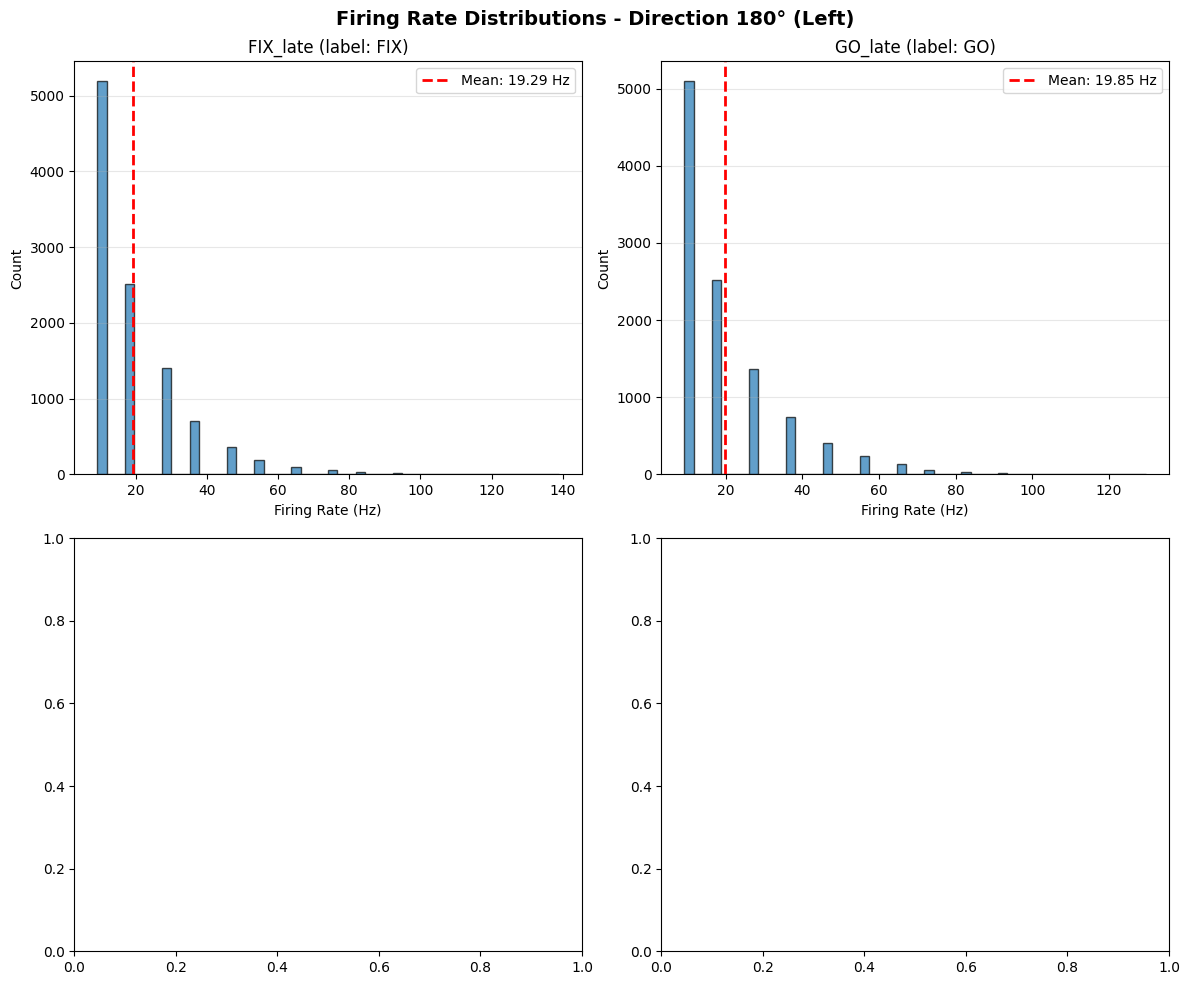

Raw feature statistics:
  Mean firing rate across all epochs: 19.57 Hz
  Std firing rate across all epochs: 14.44 Hz
  Sparsity (zero entries): 84.2%


In [7]:
# Plot firing rate distributions for one direction
direction = 180  # Left direction
dataset = datasets_by_dir[direction]
X = dataset['X']
y = dataset['y']
metadata = dataset['metadata']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle(f'Firing Rate Distributions - Direction {direction}° ({dir_map[direction]})', 
             fontsize=14, fontweight='bold')

# Plot for each epoch
for idx, (epoch_name, _, _, label) in enumerate(EPOCH_DEFS):
    ax = axes.flat[idx]
    
    # Get samples for this epoch
    epoch_mask = metadata['epoch_name'] == epoch_name
    X_epoch = X[epoch_mask]
    
    # Flatten all firing rates for this epoch
    all_frs = X_epoch.flatten()
    all_frs = all_frs[all_frs > 0]  # Remove zeros (missing cells)
    
    # Histogram
    ax.hist(all_frs, bins=50, edgecolor='black', alpha=0.7)
    ax.set_xlabel('Firing Rate (Hz)')
    ax.set_ylabel('Count')
    ax.set_title(f'{epoch_name} (label: {"%s" % ("FIX" if label == 0 else "GO")})')
    ax.grid(axis='y', alpha=0.3)
    
    # Add statistics
    mean_fr = all_frs.mean()
    std_fr = all_frs.std()
    ax.axvline(mean_fr, color='r', linestyle='--', linewidth=2, 
               label=f'Mean: {mean_fr:.2f} Hz')
    ax.legend()

plt.tight_layout()
plt.show()

print("Raw feature statistics:")
print(f"  Mean firing rate across all epochs: {X[X > 0].mean():.2f} Hz")
print(f"  Std firing rate across all epochs: {X[X > 0].std():.2f} Hz")
print(f"  Sparsity (zero entries): {(X == 0).sum() / X.size * 100:.1f}%")

## 8. Z-Score Normalization

Normalize features per neuron across all training samples.
This ensures each neuron contributes equally regardless of baseline firing rate.

In [8]:
def normalize_features(X_train, X_test=None):
    """
    Z-score normalize features per neuron.
    
    Parameters:
    -----------
    X_train : ndarray (n_train, n_neurons)
        Training features
    X_test : ndarray (n_test, n_neurons), optional
        Test features (normalized using training statistics)
    
    Returns:
    --------
    X_train_norm : ndarray
        Normalized training features
    X_test_norm : ndarray or None
        Normalized test features (if provided)
    neuron_stats : dict
        Mean and std per neuron
    """
    # Compute mean and std per neuron (across all training samples)
    neuron_mean = X_train.mean(axis=0)
    neuron_std = X_train.std(axis=0)
    
    # Handle neurons with zero variance (add small epsilon)
    neuron_std[neuron_std == 0] = 1.0
    
    # Normalize training data
    X_train_norm = (X_train - neuron_mean) / neuron_std
    
    # Normalize test data using training statistics
    X_test_norm = None
    if X_test is not None:
        X_test_norm = (X_test - neuron_mean) / neuron_std
    
    neuron_stats = {
        'mean': neuron_mean,
        'std': neuron_std
    }
    
    return X_train_norm, X_test_norm, neuron_stats


print("Z-score normalization will be applied after train/test split.")
print("✓ Normalization function defined")

Z-score normalization will be applied after train/test split.
✓ Normalization function defined


## 9. Train/Test Split

Split data into training and test sets with stratification to maintain FIX/GO ratio.
Then apply z-score normalization.

In [9]:
print("Creating train/test splits per direction...")
print("=" * 60)

# Store normalized datasets
normalized_datasets = {}

for direction in directions:
    print(f"\nDirection {direction}° ({dir_map[direction]}):")
    
    dataset = datasets_by_dir[direction]
    X = dataset['X']
    y = dataset['y']
    metadata = dataset['metadata']
    
    # Train/test split with stratification
    X_train, X_test, y_train, y_test, meta_train, meta_test = train_test_split(
        X, y, metadata,
        test_size=TEST_SIZE,
        stratify=y,
        random_state=RANDOM_STATE
    )
    
    print(f"  Training set: {len(X_train)} samples")
    print(f"    FIX: {(y_train == 0).sum()} ({(y_train == 0).sum() / len(y_train) * 100:.1f}%)")
    print(f"    GO: {(y_train == 1).sum()} ({(y_train == 1).sum() / len(y_train) * 100:.1f}%)")
    
    print(f"  Test set: {len(X_test)} samples")
    print(f"    FIX: {(y_test == 0).sum()} ({(y_test == 0).sum() / len(y_test) * 100:.1f}%)")
    print(f"    GO: {(y_test == 1).sum()} ({(y_test == 1).sum() / len(y_test) * 100:.1f}%)")
    
    # Apply z-score normalization
    X_train_norm, X_test_norm, neuron_stats = normalize_features(X_train, X_test)
    
    print(f"  ✓ Z-score normalization applied")
    print(f"    Training data: mean={X_train_norm.mean():.3f}, std={X_train_norm.std():.3f}")
    print(f"    Test data: mean={X_test_norm.mean():.3f}, std={X_test_norm.std():.3f}")
    
    # Store normalized datasets
    normalized_datasets[direction] = {
        'X_train': X_train_norm,
        'X_test': X_test_norm,
        'y_train': y_train,
        'y_test': y_test,
        'meta_train': meta_train,
        'meta_test': meta_test,
        'neuron_stats': neuron_stats,
        'cell_ids': dataset['cell_ids'],
        'mean_ssd': dataset['mean_ssd']
    }

print(f"\n✓ Train/test splits created and normalized for both directions")

Creating train/test splits per direction...

Direction 0° (Right):
  Training set: 696 samples
    FIX: 348 (50.0%)
    GO: 348 (50.0%)
  Test set: 174 samples
    FIX: 87 (50.0%)
    GO: 87 (50.0%)
  ✓ Z-score normalization applied
    Training data: mean=0.000, std=0.997
    Test data: mean=0.006, std=1.037

Direction 180° (Left):
  Training set: 718 samples
    FIX: 359 (50.0%)
    GO: 359 (50.0%)
  Test set: 180 samples
    FIX: 90 (50.0%)
    GO: 90 (50.0%)
  ✓ Z-score normalization applied
    Training data: mean=0.000, std=1.000
    Test data: mean=0.011, std=1.049

✓ Train/test splits created and normalized for both directions


## 10. Visualize Normalized Features

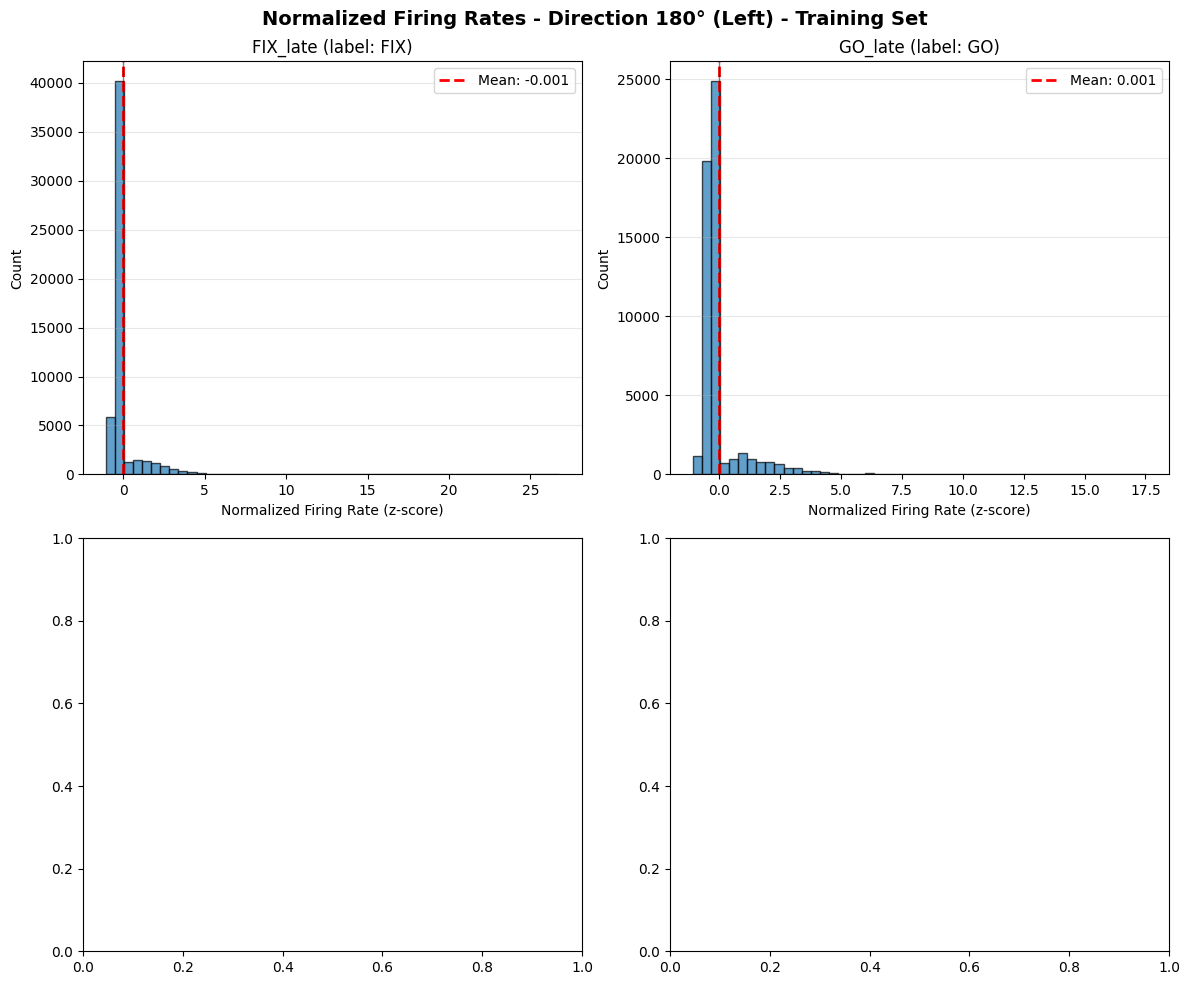

Normalized feature statistics (training set):
  Mean: 0.000
  Std: 1.000
  Min: -1.065
  Max: 26.777


In [10]:
# Plot normalized firing rate distributions
direction = 180  # Left direction
norm_dataset = normalized_datasets[direction]
X_train = norm_dataset['X_train']
y_train = norm_dataset['y_train']
meta_train = norm_dataset['meta_train']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle(f'Normalized Firing Rates - Direction {direction}° ({dir_map[direction]}) - Training Set', 
             fontsize=14, fontweight='bold')

# Plot for each epoch
for idx, (epoch_name, _, _, label) in enumerate(EPOCH_DEFS):
    ax = axes.flat[idx]
    
    # Get samples for this epoch
    epoch_mask = meta_train['epoch_name'] == epoch_name
    X_epoch = X_train[epoch_mask.values]
    
    # Flatten all normalized firing rates
    all_frs_norm = X_epoch.flatten()
    
    # Histogram
    ax.hist(all_frs_norm, bins=50, edgecolor='black', alpha=0.7)
    ax.set_xlabel('Normalized Firing Rate (z-score)')
    ax.set_ylabel('Count')
    ax.set_title(f'{epoch_name} (label: {"%s" % ("FIX" if label == 0 else "GO")})')
    ax.grid(axis='y', alpha=0.3)
    
    # Add statistics
    mean_fr = all_frs_norm.mean()
    std_fr = all_frs_norm.std()
    ax.axvline(mean_fr, color='r', linestyle='--', linewidth=2, 
               label=f'Mean: {mean_fr:.3f}')
    ax.axvline(0, color='k', linestyle='-', linewidth=1, alpha=0.5)
    ax.legend()

plt.tight_layout()
plt.show()

print("Normalized feature statistics (training set):")
print(f"  Mean: {X_train.mean():.3f}")
print(f"  Std: {X_train.std():.3f}")
print(f"  Min: {X_train.min():.3f}")
print(f"  Max: {X_train.max():.3f}")

## 11. Summary Statistics

In [11]:
print("\n" + "=" * 80)
print("PHASE 1 COMPLETE: DATA PREPARATION SUMMARY")
print("=" * 80)

for direction in directions:
    norm_dataset = normalized_datasets[direction]
    
    print(f"\n{dir_map[direction]} Direction ({direction}°):")
    print("-" * 60)
    print(f"  mean_ssd2: {norm_dataset['mean_ssd']:.2f} ms")
    print(f"  Number of neurons: {len(norm_dataset['cell_ids'])}")
    print(f"  Training samples: {len(norm_dataset['X_train'])}")
    print(f"  Test samples: {len(norm_dataset['X_test'])}")
    print(f"  Feature dimensions: {norm_dataset['X_train'].shape[1]}")
    print(f"\n  Class distribution (train):")
    print(f"    FIX: {(norm_dataset['y_train'] == 0).sum()}")
    print(f"    GO: {(norm_dataset['y_train'] == 1).sum()}")
    print(f"\n  Class distribution (test):")
    print(f"    FIX: {(norm_dataset['y_test'] == 0).sum()}")
    print(f"    GO: {(norm_dataset['y_test'] == 1).sum()}")

print("\n" + "=" * 80)
print("✓ Ready for Phase 2: Decoder Training")
print("=" * 80)


PHASE 1 COMPLETE: DATA PREPARATION SUMMARY

Right Direction (0°):
------------------------------------------------------------
  mean_ssd2: 108.00 ms
  Number of neurons: 150
  Training samples: 696
  Test samples: 174
  Feature dimensions: 150

  Class distribution (train):
    FIX: 348
    GO: 348

  Class distribution (test):
    FIX: 87
    GO: 87

Left Direction (180°):
------------------------------------------------------------
  mean_ssd2: 108.00 ms
  Number of neurons: 150
  Training samples: 718
  Test samples: 180
  Feature dimensions: 150

  Class distribution (train):
    FIX: 359
    GO: 359

  Class distribution (test):
    FIX: 90
    GO: 90

✓ Ready for Phase 2: Decoder Training


## 12. Save Prepared Data

Save the prepared datasets for use in Phase 2.

In [12]:
import pickle

# Create output directory in data/
output_dir = Path.cwd().parents[1] / 'data' / 'decoder_data'
output_dir.mkdir(exist_ok=True, parents=True)

# Save datasets
output_file = output_dir / f'decoder_data_{session_id}_ssd{SSD_NUM}.pkl'

save_data = {
    'session_id': session_id,
    'ssd_number': SSD_NUM,
    'rt_multiplier': RT_MULTIPLIER,
    'test_size': TEST_SIZE,
    'random_state': RANDOM_STATE,
    'epoch_defs': EPOCH_DEFS,
    'datasets': normalized_datasets
}

with open(output_file, 'wb') as f:
    pickle.dump(save_data, f)

print(f"✓ Prepared data saved to: {output_file}")
print(f"  File size: {output_file.stat().st_size / 1024:.1f} KB")

✓ Prepared data saved to: /home/barak/Projects/population-analysis/data/decoder_data/decoder_data_fi211025a_ssd2.pkl
  File size: 2174.4 KB


---

## Phase 1 Checklist - COMPLETE ✓

- [x] Load cell_df and compute mean_ssd2 per direction
- [x] Filter GO trials (successful, RT > 1.3×mean_ssd2)
- [x] Split by direction (0° and 180°)
- [x] Extract epochs and labels
- [x] Z-score normalize features
- [x] Train/test split (stratified)

**Next Steps**: Phase 2 - Decoder Training (Logistic Regression & Xie Decoder)